In [ ]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')


from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function, plot_full_connectivity_tree_style
from test_schwefel.schwefel_function_jax import Schwefel2D, schwefel_loss
from connectivity.connectivity import optimize_lbfgs

from connectivity.saddle_tree_calculations import saddle_tree_calculations
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
critical_points_file = "./critical_points_schwefel.csv"

outdir = './results/'

dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel2D(*p)

print(dataframe)

          x1        x2   f_value     type
0   0.341809  0.824375  0.181697  minimum
1   0.341809  0.341809  0.398836  minimum
2   0.034551  0.034551  0.675253  minimum
3   0.824375  0.824375 -0.035443  minimum
4   0.341809  0.034551  0.537045  minimum
5   0.034551  0.341809  0.537045  minimum
6   0.824375  0.341809  0.181697  minimum
7   0.824375  0.034551  0.319905  minimum
8   0.034551  0.824375  0.319905  minimum
9   0.824375  0.166287  0.506416   saddle
10  0.341809  0.561167  0.901224   saddle
11  0.166287  0.341809  0.723556   saddle
12  0.561167  0.341809  0.901224   saddle
13  0.561167  0.824375  0.684084   saddle
14  0.166287  0.824375  0.506416   saddle
15  0.824375  0.561167  0.684084   saddle
16  0.034551  0.561167  1.039432   saddle
17  0.341809  0.166287  0.723556   saddle
18  0.034551  0.166287  0.861764   saddle
19  0.166287  0.034551  0.861764   saddle


In [3]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           return_paths=True)


In [4]:
save_descent_paths(paths, out_dir=outdir+'descent_paths/')
extract_connection_indices(all_results, dataframe, out_dir=outdir)
saddle_tree_calculations(all_results, minima, dataframe, out_dir=outdir)

connectivity_df=pd.read_csv(outdir+"/connectivity_graph.csv")

Saved 22 connections to ./results//connectivity_graph.csv
Saved node order to ./results/tree_nodes.csv
Saved tree edges to ./results/tree_connectivity.csv


/var/folders/87/h8fnyth55477f11hgmy38l4h0000gn/T/ipykernel_84017/3201057130.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


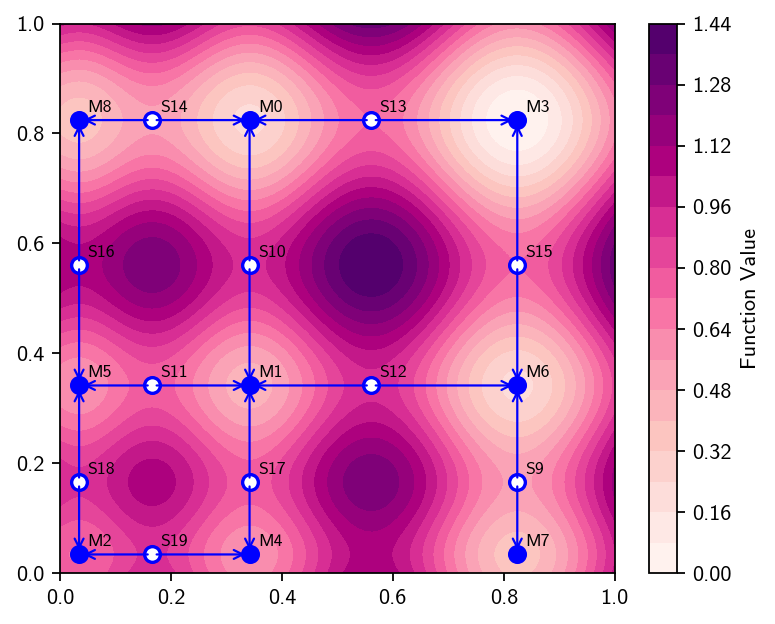

In [ ]:
from schwefel_function_jax import _schwefel
schwefel2D_numpy = _schwefel

fig2 = plt.figure(figsize=(5,4), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_df=dataframe,
                                connectivity_df=connectivity_df, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
fig2.show()
fig2.savefig(outdir+"/landscape_paths.png")  # Optional

/var/folders/87/h8fnyth55477f11hgmy38l4h0000gn/T/ipykernel_84017/917065622.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


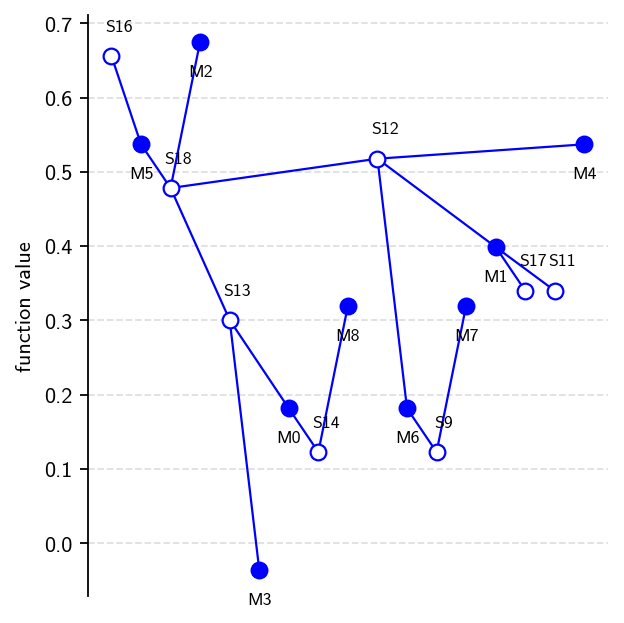

In [6]:
fig1 = plt.figure(figsize=(4,4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv=outdir+"/tree_nodes.csv",
                                      edges_csv=outdir+"/tree_connectivity.csv", 
                                      fig=fig1,
                                      txt_pads=(5e-1, 4e-2))

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig(outdir+"/tree_plot.png")  # Optional